# Example: Rebalancing Engine and Scorecard

In this example, we turn the Cobb-Douglas allocator from the previous notebook into a production-style engine and measure what it buys us. The engine, the scorecard, and the elasticity sweep together frame the question the next notebook asks on 5,000 paths.

> __Learning Objectives:__
>
> * __Run the Cobb-Douglas rebalancing engine:__ Execute the rebalancing engine with production-style trigger rules including drawdown limits and turnover caps. Observe how tighter or looser drawdown thresholds affect capital protection and recovery.
> * __Produce a strategy scorecard:__ Build a four-row scorecard comparing the AI engine to the Session 1 min-var portfolio, an equal-weight buy-and-hold, and a risk-free benchmark. Evaluate return, volatility, Sharpe ratio, and maximum drawdown across strategies.
> * __Sweep CES elasticity inside the engine:__ Run the rebalancing engine with four CES elasticity values plus an adaptive elasticity variant, and compare wealth trajectories and scorecard metrics. Identify which end of the elasticity axis rewards conviction versus diversification on this path.

Let's dive in!

___

## Setup, Data and Prerequisites
We begin by loading our packages and helper functions via [the `Include.jl` file](./Include.jl). This activates the local [Julia](https://julialang.org) environment and loads all dependencies.

In [1]:
# --- Load packages and helper functions ---
include("Include.jl"); # The Include.jl file activates the local Julia environment and imports all dependencies.

### Constants
In the section below, we set some constants that will be used throughout the notebook. We can modify these constants to explore different scenarios and allocations. 

See the comments in the code for more details on each constant, its purpose, units, etc.

In [2]:
# Scorecard configuration
ENGINE_RUN_DATA_PATH = joinpath(_PATH_TO_DATA, "engine-run-data.jld2")  # path to Example 1 hand-off file
Δt = 1.0 / 252.0              # trading-day step (years)
L_short = 21                  # short EMA window (days), must match Example 1
L_long = 63                   # long EMA window (days), must match Example 1
offset = L_short + L_long     # warmup offset before trading begins (days)
n_trading_days = 252          # trading horizon after warmup (days)

252

Load the data produced by the `BuildCobbDouglasAllocator` notebook (Example 1 in this session). In the code block below, we read `engine-run-data.jld2` and return the following bindings: `my_tickers::Vector{String}`, `price_matrix::Matrix{Float64}`, `market_prices::Vector{Float64}`, `lambda_series::Vector{Float64}`, `gm_ema::Vector{Float64}`, `sim_params::Dict{String,Tuple{Float64,Float64,Float64}}`, `context::MyRebalancingContextModel`, the three baseline wealth series `minvar_wealth::Vector{Float64}`, `equalweight_wealth::Vector{Float64}`, `riskfree_wealth::Vector{Float64}`, and the derived scalars `g_f::Float64`, `B₀::Float64`, `N::Int`.

In [3]:
my_tickers, price_matrix, lambda_series, market_prices, gm_ema, sim_params, context, minvar_wealth, equalweight_wealth, riskfree_wealth, g_f, B₀, N = let
    # --- Step 1: Load saved data from Example 1 ---
    data = load_results(ENGINE_RUN_DATA_PATH);

    # --- Step 2: Extract market and engine data into top-level bindings ---
    my_tickers         = data["my_tickers"]::Vector{String};
    price_matrix       = data["price_matrix"]::Matrix{Float64};
    lambda_series      = data["lambda_series"]::Vector{Float64};
    market_prices      = data["market_prices"]::Vector{Float64};
    gm_ema             = data["gm_ema"]::Vector{Float64};
    sim_params         = data["sim_params"]::Dict{String,Tuple{Float64,Float64,Float64}};
    context            = data["context"]::MyRebalancingContextModel;
    minvar_wealth      = Float64.(data["minvar_wealth"]);
    equalweight_wealth = Float64.(data["equalweight_wealth"]);
    riskfree_wealth    = Float64.(data["riskfree_wealth"]);
    g_f                = Float64(data["g_f"]);

    # --- Step 3: Derived dimensions ---
    B₀             = context.B;            # initial budget from the context
    N              = length(my_tickers);   # number of assets in the portfolio

    println("Loaded engine data: $(N) tickers, $(n_trading_days) trading days after $(offset) warmup")
    println("  Tickers: $(my_tickers)")
    println("  g_f (continuous, %/yr): $(round(g_f*100, digits=2))")
    my_tickers, price_matrix, lambda_series, market_prices, gm_ema, sim_params, context, minvar_wealth, equalweight_wealth, riskfree_wealth, g_f, B₀, N
end


Loaded engine data: 20 tickers, 252 trading days after 84 warmup
  Tickers: ["VZ", "T", "MCD", "PG", "KO", "PEP", "WMT", "XOM", "CVX", "JPM", "BRK.B", "JNJ", "MRK", "HON", "UPS", "AAPL", "MSFT", "APD", "AMT", "NEE"]
  g_f (continuous, %/yr): 4.5


(["VZ", "T", "MCD", "PG", "KO", "PEP", "WMT", "XOM", "CVX", "JPM", "BRK.B", "JNJ", "MRK", "HON", "UPS", "AAPL", "MSFT", "APD", "AMT", "NEE"], [1.0 40.73 … 175.57 80.28; 2.0 40.91225279856964 … 175.24957010095764 80.01054497614588; … ; 335.0 35.483936120769435 … 160.22403328185604 79.86155644336469; 336.0 35.393240790856424 … 159.50891302473136 78.9286634674355], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.14004160179568625, 0.14891543640320526, 0.14507441903269025, 0.13620626965207605, 0.13770701432429533, 0.11712203196430293, 0.1220393754348903, 0.11743922562327258, 0.11085443482435897, 0.10896863119703726], [681.92, 679.8591512862722, 677.9297265774395, 673.4436285316499, 675.2079291808494, 680.5171446584945, 679.8731816887454, 680.07600055041, 674.2318585978346, 675.6201249944437  …  597.3298387661029, 593.4117154839053, 604.9207627390249, 610.1099889192898, 600.1957559640781, 622.1973316910169, 598.2823814658013, 607.0675405026404, 609.316688942681, 604.9946846986921], 

### Implementation
We define one helper function used later to compute per-strategy performance metrics for the scorecard table.

> __`scorecard_metrics(wealth, label; rf_growth_pct=0.0)`__
>
> Computes performance metrics from a daily wealth time series in continuously-compounded growth-rate units. Takes a `Vector{Float64}` of daily wealth values and a `String` strategy label, and returns a tuple `(label, total_growth, volatility, sharpe_ratio, max_drawdown)` with growth, volatility, and drawdown expressed as percentages per year. Growth is the annualized CC rate $g = \ln(W_T / W_0) / \Delta t_\text{yr}$ where $\Delta t_\text{yr}$ is the series horizon in years; volatility is the annualized std of daily log returns; Sharpe uses the excess growth over the risk-free benchmark supplied via `rf_growth_pct`.

The helper definition appears in the code cell below.

In [4]:
"""
    scorecard_metrics(wealth::Array{Float64,1}, label::String; rf_growth_pct::Float64 = 0.0) -> Tuple

Compute performance metrics from a daily wealth time series using continuously-compounded growth rates.

### Arguments
- `wealth::Array{Float64,1}`: daily wealth values (e.g., portfolio value over time).
- `label::String`: strategy name used to tag the output row.

### Keyword Arguments
- `rf_growth_pct::Float64`: annualized continuously-compounded risk-free growth rate (%/yr),
   subtracted from the strategy's growth before computing Sharpe. Default `0.0` yields an
   un-risk-adjusted Sharpe.

### Returns
A tuple `(label, total_growth, volatility, sharpe_ratio, max_drawdown)` where growth, volatility,
and max drawdown are expressed as percentages (growth and volatility are in %/yr). Growth is the
annualized CC rate g = ln(W_T / W_0) / Δt_yr; volatility is the annualized std of daily log returns;
Sharpe uses the excess growth over the risk-free benchmark.
"""
function scorecard_metrics(wealth::Array{Float64,1}, label::String; rf_growth_pct::Float64 = 0.0)

    # --- Step 1: Compute daily log returns (CCGR convention) ---
    daily_log_returns = diff(log.(wealth));

    # --- Step 2: Annualized CC growth rate (%/yr): g = ln(W_T / W_0) / horizon_yr ---
    horizon_yr   = (length(wealth) - 1) * Δt;
    total_growth = log(wealth[end] / wealth[1]) / horizon_yr * 100;

    # --- Step 3: Annualized volatility from daily log returns (%/yr) ---
    vol = std(daily_log_returns) * sqrt(252) * 100;

    # --- Step 4: Sharpe on the excess CC growth over the risk-free benchmark ---
    # Guard against deterministic series (e.g. the risk-free curve compounded at constant g_f).
    # std of a constant stream is numerically ~1e-15 rather than exactly zero, so `vol > 0` is
    # not strict enough — we need a tolerance well above FP noise but well below any real
    # asset's annualized vol.
    excess_growth = total_growth - rf_growth_pct;
    sharpe = vol > 1e-6 ? excess_growth / vol : 0.0;

    # --- Step 5: Maximum drawdown (%) ---
    peak = accumulate(max, wealth);
    dd = maximum((peak .- wealth) ./ peak) * 100;

    # --- Step 6: Return rounded metrics ---
    return (label, round(total_growth, digits=2), round(vol, digits=2),
        round(sharpe, digits=2), round(dd, digits=2))
end;

___
## Task 1: Cobb-Douglas Rebalancing Engine with Trigger Rules
In this task, we run the Cobb-Douglas utility allocator inside the full rebalancing engine with realistic trigger rules: a 15% drawdown limit (circuit breaker) and a 50% turnover cap (trading cost control). We compare three drawdown thresholds to see how the safety net affects performance.

> __What should we see?__
>
> Tighter drawdown limits (10%) cause the engine to de-risk to cash earlier and more often, protecting capital but potentially missing recoveries. Looser limits (25%) allow more volatility. The engine uses Cobb-Douglas utility to decide _how_ to allocate; the trigger rules decide _whether_ to allocate.

The code below sweeps three drawdown limits using [the `run_rebalancing_engine(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/), and the results are stored in the `dd_wealth_curves::Dict{Float64, Array{Float64,1}}` variable.

Baseline max DD = 3.62%
  2% threshold: baseline DD first crosses on day 34;  engine trigger fires on day 34
  3% threshold: baseline DD first crosses on day 196;  engine trigger fires on day 196


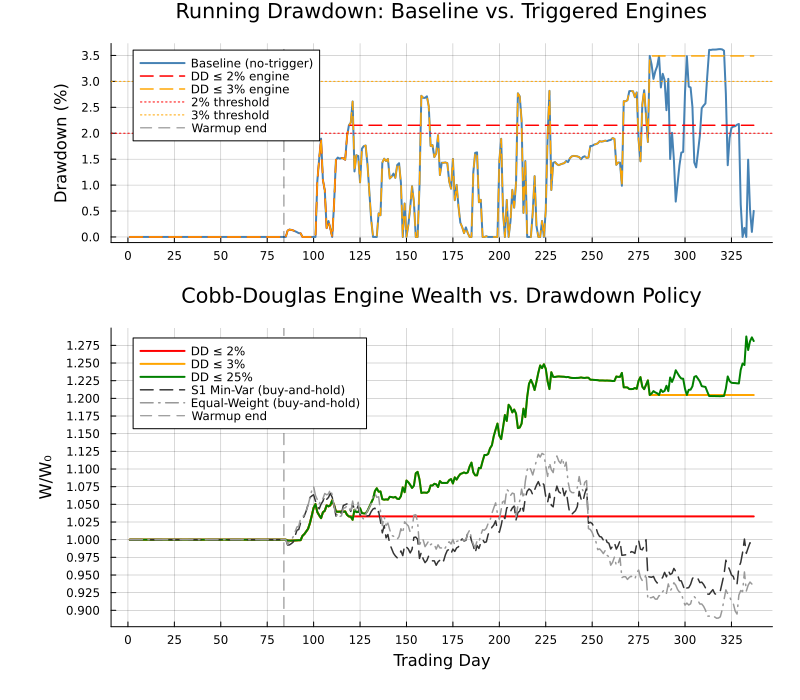

In [5]:
dd_wealth_curves = let
    # --- Step 1: Define drawdown thresholds and plot styling ---
    drawdown_limits = [0.02, 0.03, 0.25];                 # three drawdown trigger levels to compare
    colors          = [:red :orange :green];               # color per threshold
    labels          = ["DD ≤ 2%", "DD ≤ 3%", "DD ≤ 25%"];  # legend labels

    # Storage: maps each drawdown limit to its wealth curve
    dd_wealth_curves = Dict{Float64, Array{Float64,1}}();

    # Helper: prepend flat W₀ values for the warmup window so the x-axis
    # aligns with the Allocator notebook's full 1:T_total market-day axis.
    with_warmup(w) = [fill(B₀, offset); w];

    # --- Step 2: Sweep drawdown limits and store each wealth trajectory ---
    for dd_limit ∈ drawdown_limits
        rules = build(MyTriggerRules, (
            max_drawdown = dd_limit,
            max_turnover = 0.50,
            rebalance_schedule = ones(Int, n_trading_days)  # rebalance every day
        ));
        results = run_rebalancing_engine(context, rules, lambda_series;
            offset = offset, allocator = :cobb_douglas);
        wealth  = compute_wealth_series(results, price_matrix, my_tickers; offset = offset);
        dd_wealth_curves[dd_limit] = wealth;
    end

    # --- Step 3: Running drawdown on each engine's OWN wealth path ---
    running_dd_by = Dict{Float64,Vector{Float64}}();
    for dd_limit ∈ drawdown_limits
        w  = dd_wealth_curves[dd_limit];
        pk = accumulate(max, w);
        running_dd_by[dd_limit] = (pk .- w) ./ pk;
    end
    baseline_dd = running_dd_by[0.25];  # 25% never fires ⇒ identical to a no-trigger run
    max_dd_pct  = round(maximum(baseline_dd) * 100, digits = 2);

    # --- Step 4: Diagnostic — compare baseline DD crossings with engine flatline days ---
    # If the trigger fires correctly, engine first flatlines at (crossing_day + 1).
    println("Baseline max DD = $(max_dd_pct)%")
    for (thr, lbl) ∈ zip([0.02, 0.03], ["2%", "3%"])
        idx_cross = findfirst(x -> x > thr, baseline_dd);
        cross_day = idx_cross === nothing ? nothing : idx_cross - 1;

        w_eng    = dd_wealth_curves[thr];
        idx_flat = findfirst(i -> abs(w_eng[i+1] - w_eng[i]) < 1e-6, 1:length(w_eng)-1);
        # wealth[k+1]==wealth[k] means trading day k is where the engine first holds
        # (so the trigger fired on trading day k-1).
        trigger_day = idx_flat === nothing ? nothing : idx_flat - 1;

        c = cross_day === nothing ? "never"      : "day $(cross_day)";
        t = trigger_day === nothing ? "never"    : "day $(trigger_day)";
        println("  $(lbl) threshold: baseline DD first crosses on $(c);  engine trigger fires on $(t)")
    end

    # --- Step 5: Top panel — running DD for baseline AND each triggered engine ---
    p_top = plot(ylabel = "Drawdown (%)",
        title = "Running Drawdown: Baseline vs. Triggered Engines",
        legend = :topleft,
        xticks = 0:25:350, yticks = 0:0.5:5,
        grid = true, gridalpha = 0.3,
        left_margin = 10Plots.mm, right_margin = 5Plots.mm,
        top_margin = 3Plots.mm, bottom_margin = 3Plots.mm)
    plot!(p_top, 1:(offset + length(baseline_dd)), [zeros(offset); baseline_dd] .* 100,
        label = "Baseline (no-trigger)", linewidth = 2, color = :steelblue)
    for (j, dd_limit) ∈ enumerate([0.02, 0.03])
        rdd      = running_dd_by[dd_limit];
        dd_full  = [zeros(offset); rdd];
        plot!(p_top, 1:length(dd_full), dd_full .* 100,
            label = "$(labels[j]) engine", linewidth = 1.5, color = colors[j], linestyle = :dash)
    end
    hline!(p_top, [2.0], linestyle = :dot, color = :red,    label = "2% threshold")
    hline!(p_top, [3.0], linestyle = :dot, color = :orange, label = "3% threshold")
    vline!(p_top, [offset], linestyle = :dash, color = :black, alpha = 0.5, label = "Warmup end")

    # --- Step 6: Bottom panel — W/W₀ curves for each engine run plus the two baselines ---
    p_bot = plot(xlabel = "Trading Day", ylabel = "W/W₀",
        title = "Cobb-Douglas Engine Wealth vs. Drawdown Policy",
        legend = :topleft,
        xticks = 0:25:350, yticks = 0.85:0.025:1.35,
        grid = true, gridalpha = 0.3,
        left_margin = 10Plots.mm, right_margin = 5Plots.mm,
        top_margin = 3Plots.mm, bottom_margin = 6Plots.mm)
    for (j, dd_limit) ∈ enumerate(drawdown_limits)
        w_full = with_warmup(dd_wealth_curves[dd_limit]);
        plot!(p_bot, 1:length(w_full), w_full ./ B₀, label = labels[j], linewidth = 2, color = colors[j])
    end
    mv_full  = with_warmup(minvar_wealth);
    eqw_full = with_warmup(equalweight_wealth);
    plot!(p_bot, 1:length(mv_full), mv_full ./ B₀,
        label = "S1 Min-Var (buy-and-hold)", linewidth = 1.5, color = :gray20, linestyle = :dash)
    plot!(p_bot, 1:length(eqw_full), eqw_full ./ B₀,
        label = "Equal-Weight (buy-and-hold)", linewidth = 1.5, color = :gray60, linestyle = :dashdot)
    vline!(p_bot, [offset], linestyle = :dash, color = :black, alpha = 0.5, label = "Warmup end")

    # --- Step 7: Combine panels and render ---
    p_combined = plot(p_top, p_bot, layout = grid(2, 1, heights = [0.40, 0.60]), size = (800, 700))
    display(p_combined)
    dd_wealth_curves
end;


___
## Task 2: Scorecard, Engine vs. Baselines
In this task, we produce a scorecard comparing three strategies: the AI Cobb-Douglas engine (DD $\leq$ 15%, $\tau \leq$ 50%), equal-weight buy-and-hold, and risk-free. The scorecard tracks return, volatility, Sharpe ratio, and maximum drawdown.

> __What should we see?__
>
> The engine should show better risk-adjusted performance (lower drawdown, potentially better Sharpe) than static allocations, at the cost of higher trading activity. The scorecard quantifies exactly how much adaptability costs and what it buys.

In the code block below, we run the engine via [the `run_rebalancing_engine(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/), compute per-strategy metrics, print the scorecard, and return `engine_wealth::Vector{Float64}` (the AI engine's daily wealth trajectory) for use in downstream plots.

In [6]:
engine_wealth = let
    # --- Step 1: Run the moderate engine configuration (DD ≤ 15%, τ ≤ 50%) ---
    rules = build(MyTriggerRules, (
        max_drawdown = 0.15, max_turnover = 0.50,
        rebalance_schedule = ones(Int, n_trading_days)
    ));
    results = run_rebalancing_engine(context, rules, lambda_series;
        offset=offset, allocator=:cobb_douglas);
    engine_wealth = compute_wealth_series(results, price_matrix, my_tickers; offset=offset);

    # --- Step 2: Risk-free annualized CC growth rate (for excess-growth Sharpe) ---
    rf_horizon_yr = (length(riskfree_wealth) - 1) * Δt;
    rf_growth_pct = log(riskfree_wealth[end] / riskfree_wealth[1]) / rf_horizon_yr * 100;

    # --- Step 3: Compute metrics for each strategy ---
    rf_label = "Risk-Free ($(round(g_f*100, digits=2))%)";
    eng = scorecard_metrics(engine_wealth,      "Cobb-Douglas Engine (DD≤15%, τ≤50%)"; rf_growth_pct = rf_growth_pct);
    mv  = scorecard_metrics(minvar_wealth,      "S1 Min-Var (buy-and-hold)";            rf_growth_pct = rf_growth_pct);
    eqw = scorecard_metrics(equalweight_wealth, "Equal-Weight (buy-and-hold)";          rf_growth_pct = rf_growth_pct);
    rf  = scorecard_metrics(riskfree_wealth,    rf_label;                               rf_growth_pct = rf_growth_pct);

    # --- Step 4: NPV of terminal wealth, discounted at the risk-free rate, scaled by W₀ ---
    # Each wealth series has its own horizon (length − 1 trading steps), so discount per-series
    # to keep the risk-free row exactly zero (it's compounded and discounted over the same span).
    npv_ratio(w) = (w[end] * exp(-g_f * (length(w) - 1) * Δt) - w[1]) / w[1];

    # --- Step 5: Build and display the scorecard table ---
    scorecard = DataFrame(
        "Strategy"         => [eng[1], mv[1], eqw[1], rf[1]],
        "Growth (%/yr)"    => [eng[2], mv[2], eqw[2], rf[2]],
        "Volatility (%/yr)"=> [eng[3], mv[3], eqw[3], rf[3]],
        "Sharpe Ratio"     => [eng[4], mv[4], eqw[4], rf[4]],
        "Max Drawdown (%)" => [eng[5], mv[5], eqw[5], rf[5]],
        "NPV/W₀"           => [round(npv_ratio(engine_wealth),      digits=4),
                                round(npv_ratio(minvar_wealth),      digits=4),
                                round(npv_ratio(equalweight_wealth), digits=4),
                                round(npv_ratio(riskfree_wealth),    digits=4)]
    );

    println("═"^70)
    println("  SESSION 2 SCORECARD: Cobb-Douglas Engine vs. S1 + Baselines")
    println("═"^70)
    pretty_table(scorecard; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    # --- Step 6: Save results for downstream sessions ---
    save_results(joinpath(_PATH_TO_DATA, "session2-scorecard.jld2"), Dict(
        "scorecard"          => scorecard,
        "engine_wealth"      => engine_wealth,
        "minvar_wealth"      => minvar_wealth,
        "equalweight_wealth" => equalweight_wealth,
        "riskfree_wealth"    => riskfree_wealth,
    ));
    engine_wealth
end;

══════════════════════════════════════════════════════════════════════
  SESSION 2 SCORECARD: Cobb-Douglas Engine vs. S1 + Baselines
══════════════════════════════════════════════════════════════════════
 ------------------------------------- --------------- ------------------- -------------- ------------------ ---------
                             Strategy   Growth (%/yr)   Volatility (%/yr)   Sharpe Ratio   Max Drawdown (%)    NPV/W₀ 
                               String         Float64             Float64        Float64            Float64   Float64 
 ------------------------------------- --------------- ------------------- -------------- ------------------ ---------
  Cobb-Douglas Engine (DD≤15%, τ≤50%)           24.77               10.65            1.9               3.62    0.2247
            S1 Min-Var (buy-and-hold)           -0.77               14.53          -0.36              14.79   -0.0511
          Equal-Weight (buy-and-hold)           -6.51               16.36          -

The code below plots the wealth curves for all four strategies (engine, S1 min-var, equal-weight, risk-free) on a single axis.

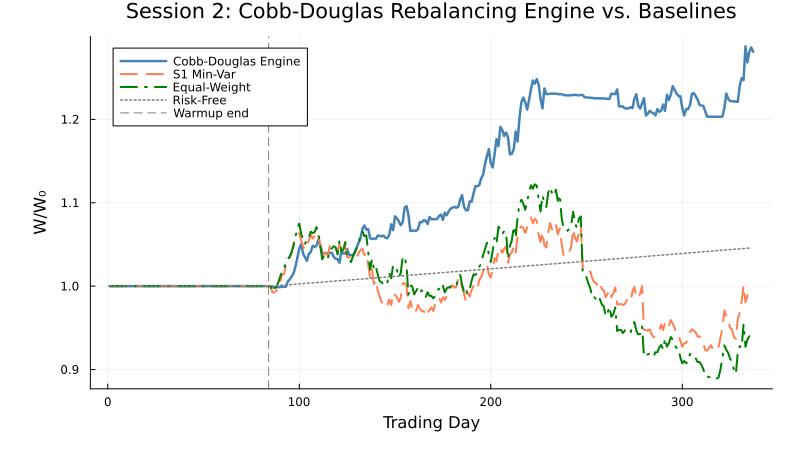

In [7]:
let
    # --- Step 1: Prepend the warmup window (flat at B₀) so all curves share the market-day axis ---
    with_warmup(w) = [fill(B₀, offset); w];
    engine_full = with_warmup(engine_wealth);
    mv_full     = with_warmup(minvar_wealth);
    eqw_full    = with_warmup(equalweight_wealth);
    rf_full     = with_warmup(riskfree_wealth);

    # --- Step 2: Plot each strategy on the full market-day axis (scaled by B₀) ---
    p = plot(1:length(engine_full), engine_full ./ B₀,
        label="Cobb-Douglas Engine", linewidth=2.5, color=:steelblue)
    plot!(p, 1:length(mv_full),  mv_full  ./ B₀, label="S1 Min-Var",   linewidth=2,   color=:coral,  linestyle=:dash)
    plot!(p, 1:length(eqw_full), eqw_full ./ B₀, label="Equal-Weight", linewidth=2,   color=:green,  linestyle=:dashdot)
    plot!(p, 1:length(rf_full),  rf_full  ./ B₀, label="Risk-Free",    linewidth=1.5, color=:gray50, linestyle=:dot)
    vline!(p, [offset], label="Warmup end", linestyle=:dash, color=:black, alpha=0.5)

    # --- Step 3: Axis labels, margins, and formatting ---
    xlabel!(p, "Trading Day")
    ylabel!(p, "W/W₀")
    title!(p, "Session 2: Cobb-Douglas Rebalancing Engine vs. Baselines")
    plot!(p, size=(800, 450), legend=:topleft,
        left_margin = 10Plots.mm, right_margin = 5Plots.mm,
        top_margin = 3Plots.mm, bottom_margin = 6Plots.mm)
    p
end

___
## Task 3: CES Elasticity Sweep — How Concentration Tunes Engine Behavior
In this task, we swap the allocator inside the rebalancing engine from Cobb-Douglas to CES utility and run the engine at four elasticity values: $\eta \in \{0.5, 1.0, 2.0, 3.0\}$. CES with $\eta = 1$ is the Cobb-Douglas limit (same allocation, same wealth path); $\eta > 1$ concentrates more budget in the single best-scoring asset, $\eta < 1$ diversifies more aggressively. By holding trigger rules and sentiment fixed, the η sweep isolates the effect of *how much* the allocator reacts to its own preference weights.

> __What should we see?__
>
> The $\eta = 1$ CES run should overlay the Cobb-Douglas engine almost exactly (they're the same allocation — the matching is a sanity check on the library's CES path). As $\eta$ grows, wealth trajectories diverge from Cobb-Douglas: high-$\eta$ runs place larger bets on the top-γ asset each day, which amplifies upside in trending regimes and downside in choppy ones. Low-$\eta$ runs look smoother but typically underperform because they spread budget even across weakly-preferred assets.

In the code block below, we run the rebalancing engine four times (once per η value), each with the same trigger rules (DD ≤ 15%, τ ≤ 50%) and the same $\lambda$ series from Task 1. The per-η wealth series are stored in the `ces_wealth_curves::Dict{Float64,Vector{Float64}}` dictionary.

In [8]:
ces_wealth_curves = let
    # --- Step 1: Define the η grid ---
    # η = 1 is the Cobb-Douglas limit (sanity check row).
    η_values = [0.5, 1.0, 2.0, 3.0];

    # --- Step 2: Trigger rules and sentiment shared across all runs ---
    rules = build(MyTriggerRules, (
        max_drawdown = 0.15, max_turnover = 0.50,
        rebalance_schedule = ones(Int, n_trading_days)
    ));

    # --- Step 3: Run the engine once per η and store the wealth series ---
    ces_wealth_curves = Dict{Float64, Vector{Float64}}();
    for η ∈ η_values
        results_η = run_rebalancing_engine(context, rules, lambda_series;
            offset = offset, allocator = :ces, eta = η);
        wealth_η  = compute_wealth_series(results_η, price_matrix, my_tickers; offset = offset);
        ces_wealth_curves[η] = wealth_η;
    end

    println("CES engine runs complete for η ∈ $(η_values)")
    for η ∈ η_values
        w = ces_wealth_curves[η];
        println("  η=$(η):  W/W₀ final = $(round(w[end]/B₀, digits=3)),  max = $(round(maximum(w)/B₀, digits=3))")
    end
    ces_wealth_curves
end;


CES engine runs complete for η ∈ [0.5, 1.0, 2.0, 3.0]
  η=0.5:  W/W₀ final = 1.276,  max = 1.283
  η=1.0:  W/W₀ final = 1.281,  max = 1.288
  η=2.0:  W/W₀ final = 1.292,  max = 1.297
  η=3.0:  W/W₀ final = 1.303,  max = 1.309


The code below plots the four CES wealth trajectories on a single axis, with the Cobb-Douglas engine and the S1 min-var baseline as reference lines.

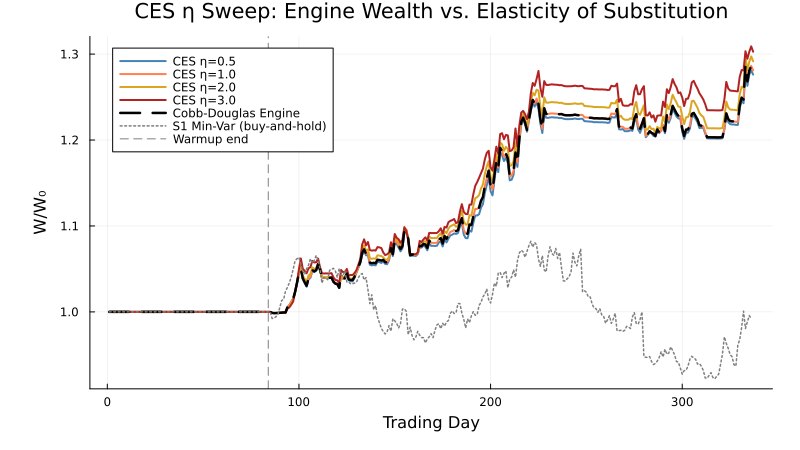

In [9]:
let
    with_warmup(w) = [fill(B₀, offset); w];
    η_values = sort(collect(keys(ces_wealth_curves)));
    palette = [:steelblue, :coral, :goldenrod, :firebrick];

    # --- Step 1: Plot the four CES runs on the full market-day axis (scaled by B₀) ---
    p = plot(size=(800, 450), legend=:topleft,
        title="CES η Sweep: Engine Wealth vs. Elasticity of Substitution",
        xlabel="Trading Day", ylabel="W/W₀",
        left_margin = 10Plots.mm, right_margin = 5Plots.mm,
        top_margin = 3Plots.mm, bottom_margin = 6Plots.mm)
    for (k, η) ∈ enumerate(η_values)
        w_full = with_warmup(ces_wealth_curves[η]);
        plot!(p, 1:length(w_full), w_full ./ B₀,
            label="CES η=$(η)", linewidth=2, color=palette[k])
    end

    # --- Step 2: Overlay the Cobb-Douglas engine and S1 min-var for reference ---
    eng_full = with_warmup(engine_wealth);
    mv_full  = with_warmup(minvar_wealth);
    plot!(p, 1:length(eng_full), eng_full ./ B₀,
        label="Cobb-Douglas Engine", linewidth=2.5, color=:black, linestyle=:dash)
    plot!(p, 1:length(mv_full), mv_full ./ B₀,
        label="S1 Min-Var (buy-and-hold)", linewidth=1.5, color=:gray50, linestyle=:dot)
    vline!(p, [offset], label="Warmup end", linestyle=:dash, color=:black, alpha=0.5)
    p
end


The code below extends the Task 2 scorecard with one row per CES run, so return, volatility, Sharpe, and drawdown are directly comparable across η values and against the Cobb-Douglas engine and baselines.

In [10]:
let
    # --- Step 1: Risk-free annualized CC growth rate (for excess-growth Sharpe) ---
    rf_horizon_yr = (length(riskfree_wealth) - 1) * Δt;
    rf_growth_pct = log(riskfree_wealth[end] / riskfree_wealth[1]) / rf_horizon_yr * 100;

    # --- Step 2: Metrics for each CES run ---
    η_values = sort(collect(keys(ces_wealth_curves)));
    ces_rows = [scorecard_metrics(ces_wealth_curves[η], "CES Engine (η=$(η))"; rf_growth_pct = rf_growth_pct) for η ∈ η_values];

    # --- Step 3: Append to the existing four-row baseline scorecard ---
    rf_label = "Risk-Free ($(round(g_f*100, digits=2))%)";
    eng = scorecard_metrics(engine_wealth,      "Cobb-Douglas Engine (DD≤15%, τ≤50%)"; rf_growth_pct = rf_growth_pct);
    mv  = scorecard_metrics(minvar_wealth,      "S1 Min-Var (buy-and-hold)";            rf_growth_pct = rf_growth_pct);
    eqw = scorecard_metrics(equalweight_wealth, "Equal-Weight (buy-and-hold)";          rf_growth_pct = rf_growth_pct);
    rf  = scorecard_metrics(riskfree_wealth,    rf_label;                               rf_growth_pct = rf_growth_pct);

    all_rows = vcat([eng], ces_rows, [mv, eqw, rf]);

    # --- Step 4: NPV of terminal wealth, discounted at the risk-free rate, scaled by W₀ ---
    # Each wealth series has its own horizon (length − 1 trading steps), so discount per-series
    # to keep the risk-free row exactly zero (it's compounded and discounted over the same span).
    npv_ratio(w) = (w[end] * exp(-g_f * (length(w) - 1) * Δt) - w[1]) / w[1];
    all_wealths = vcat([engine_wealth],
                       [ces_wealth_curves[η] for η ∈ η_values],
                       [minvar_wealth, equalweight_wealth, riskfree_wealth]);
    npv_col = [round(npv_ratio(w), digits=4) for w ∈ all_wealths];

    # --- Step 5: Build the combined DataFrame ---
    df = DataFrame(
        "Strategy"          => [r[1] for r ∈ all_rows],
        "Growth (%/yr)"     => [r[2] for r ∈ all_rows],
        "Volatility (%/yr)" => [r[3] for r ∈ all_rows],
        "Sharpe Ratio"      => [r[4] for r ∈ all_rows],
        "Max Drawdown (%)"  => [r[5] for r ∈ all_rows],
        "NPV/W₀"            => npv_col,
    );

    println("═"^80)
    println("  SESSION 2 EXTENDED SCORECARD: CES Elasticity Sweep")
    println("═"^80)
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

════════════════════════════════════════════════════════════════════════════════
  SESSION 2 EXTENDED SCORECARD: CES Elasticity Sweep
════════════════════════════════════════════════════════════════════════════════
 ------------------------------------- --------------- ------------------- -------------- ------------------ ---------
                             Strategy   Growth (%/yr)   Volatility (%/yr)   Sharpe Ratio   Max Drawdown (%)    NPV/W₀ 
                               String         Float64             Float64        Float64            Float64   Float64 
 ------------------------------------- --------------- ------------------- -------------- ------------------ ---------
  Cobb-Douglas Engine (DD≤15%, τ≤50%)           24.77               10.65            1.9               3.62    0.2247
                   CES Engine (η=0.5)           24.39               10.62           1.87               3.44      0.22
                   CES Engine (η=1.0)           24.77               10.65

The code below identifies the best and worst η value in the sweep by final `W/W₀`, highlighting the point on the elasticity axis where the engine wins (or loses) the most.

In [11]:
let
    # --- Step 1: Collect terminal W/W₀ by η ---
    η_values = sort(collect(keys(ces_wealth_curves)));
    terminals = [(η, ces_wealth_curves[η][end] / B₀) for η ∈ η_values];

    # --- Step 2: Sort by terminal wealth ---
    sort!(terminals, by = x -> x[2], rev = true);

    # --- Step 3: Report ---
    (best_η, best_w)   = terminals[1];
    (worst_η, worst_w) = terminals[end];
    println("Best  η: $(best_η)   → W/W₀ = $(round(best_w, digits=3))")
    println("Worst η: $(worst_η)  → W/W₀ = $(round(worst_w, digits=3))")
    println()
    println("Full ranking (η → W/W₀):")
    for (η, w) ∈ terminals
        println("  η=$(η):  $(round(w, digits=3))")
    end
end;

Best  η: 3.0   → W/W₀ = 1.303
Worst η: 0.5  → W/W₀ = 1.276

Full ranking (η → W/W₀):
  η=3.0:  1.303
  η=2.0:  1.292
  η=1.0:  1.281
  η=0.5:  1.276


### Adaptive η: Letting the Engine Choose Its Own Elasticity

The static sweep above holds η constant across the entire trading horizon. But the [adaptive elasticity model](eCornell-AI-Finance-S2-Lecture-AI-RebalancingEngine-May-2026.ipynb) links η to the sentiment signal λ: concentrate when neutral, diversify when sentiment is extreme. The engine computes $\eta(\lambda_t) = \eta_{\min} + (\eta_{\max} - \eta_{\min})/(1 + |\lambda_t|)$ at each rebalance day using [the `compute_adaptive_eta(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/).

In the code block below, we run the engine with `adaptive_eta=true` and return `adaptive_wealth::Vector{Float64}` (the wealth trajectory under adaptive η) and `eta_series::Vector{Float64}` (the per-day η values). A two-panel figure overlays the adaptive run on the static CES sweep (top) and shows the η trajectory (bottom).

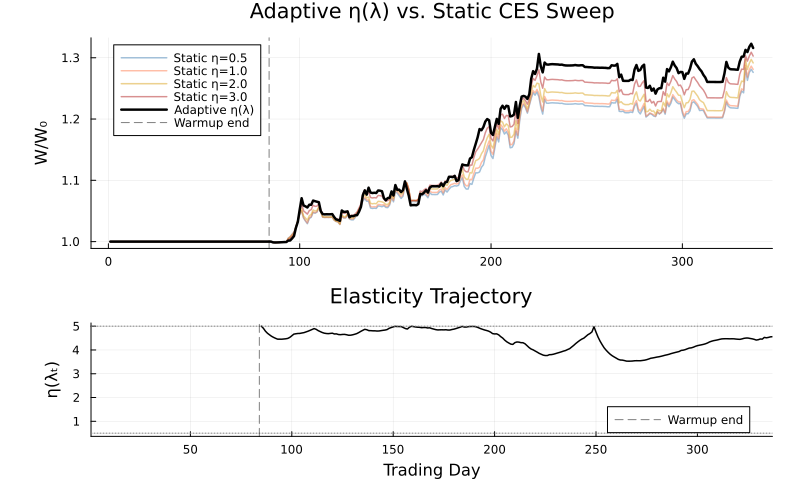

([10000.0, 9987.731215713717, 9985.727676670544, 9986.38729162244, 9987.477090918732, 9988.969590594384, 9990.715292438359, 9992.689130669381, 9993.00761432021, 10016.729110083557  …  12806.443428876764, 12804.599587196948, 12938.14935057907, 13016.928147358869, 13019.366714719878, 13128.446769890608, 13093.281782699927, 13179.13645316444, 13228.45870086852, 13159.5988945266], [5.0, 4.910895834671338, 4.790049232927193, 4.702751135545945, 4.6379525988947545, 4.5759758645585284, 4.529532753207051, 4.489082940955473, 4.454255017119994, 4.453422070105596  …  4.447224375770167, 4.416737348475097, 4.429875582934956, 4.460548467469705, 4.455324124175002, 4.52820808402407, 4.510554440886577, 4.527064646392774, 4.550935801243401, 4.557824426595938])

In [12]:
adaptive_wealth, eta_series = let
    # --- Step 1: Run the CES engine with adaptive η(λ) ---
    rules = build(MyTriggerRules, (
        max_drawdown = 0.15, max_turnover = 0.50,
        rebalance_schedule = ones(Int, n_trading_days)
    ));
    results_adaptive = run_rebalancing_engine(context, rules, lambda_series;
        offset = offset, allocator = :ces, adaptive_eta = true, eta_bounds = (0.5, 5.0));
    adaptive_wealth = compute_wealth_series(results_adaptive, price_matrix, my_tickers; offset = offset);

    # --- Step 2: Extract the per-day η series for plotting ---
    trading_days = sort(collect(keys(results_adaptive)));
    eta_series = [results_adaptive[d].eta for d in trading_days];

    # --- Step 3: Two-panel plot on the full market-day axis ---
    with_warmup(w) = [fill(B₀, offset); w];
    η_values = sort(collect(keys(ces_wealth_curves)));
    palette = [:steelblue, :coral, :goldenrod, :firebrick];

    # Panel 1: W/W₀ wealth comparison (warmup flat at 1.0)
    p1 = plot(size = (800, 300), legend = :topleft,
        title = "Adaptive η(λ) vs. Static CES Sweep",
        ylabel = "W/W₀",
        left_margin = 10Plots.mm, right_margin = 5Plots.mm,
        top_margin = 3Plots.mm, bottom_margin = 3Plots.mm)
    for (k, η) ∈ enumerate(η_values)
        w_full = with_warmup(ces_wealth_curves[η]);
        plot!(p1, 1:length(w_full), w_full ./ B₀,
            label = "Static η=$(η)", linewidth = 1.5, color = palette[k], alpha = 0.5)
    end
    adapt_full = with_warmup(adaptive_wealth);
    plot!(p1, 1:length(adapt_full), adapt_full ./ B₀,
        label = "Adaptive η(λ)", linewidth = 2.5, color = :black)
    vline!(p1, [offset], linestyle = :dash, color = :black, alpha = 0.5, label = "Warmup end")

    # Panel 2: η(λ) trajectory plotted at post-warmup market-day positions, aligned with Panel 1
    η_days = offset .+ (1:length(eta_series));
    x_max  = length(adapt_full);
    p2 = plot(η_days, eta_series,
        label = "", linewidth = 1.5, color = :black,
        xlabel = "Trading Day", ylabel = "η(λₜ)",
        title = "Elasticity Trajectory", size = (800, 200),
        xlim = (1, x_max),
        left_margin = 10Plots.mm, right_margin = 5Plots.mm,
        top_margin = 3Plots.mm, bottom_margin = 6Plots.mm)
    hline!(p2, [0.5, 5.0], linestyle = :dot, color = :gray50, label = "")
    vline!(p2, [offset], linestyle = :dash, color = :black, alpha = 0.5, label = "Warmup end")

    # --- Step 4: Combine panels, render, and return the two series ---
    p_combined = plot(p1, p2, layout = grid(2, 1, heights = [0.65, 0.35]), size = (800, 500))
    display(p_combined)
    adaptive_wealth, eta_series
end


___
## Stress Test: $\alpha$/$\beta$ Bootstrap Noise and Transaction Costs
The Task 2 scorecard reported Sharpe ≈ 2.6 on a pristine run. Two idealizations inflate that number: the allocator consumes the **exact** SIM parameters ($\alpha$, $\beta$, $\sigma_\epsilon$) used to generate the synthetic price path, and rebalancing is costless. In reality $\alpha$ and $\beta$ are estimated with noise, and trades cost basis points.

We perturb each ticker's $\alpha$ and $\beta$ by independent Gaussian draws with scale equal to the ticker's **bootstrap standard error** from the Session 1 estimation notebook (stored alongside the point estimates in `sim-parameter-estimates.jld2`), and rerun the engine at three cost levels: 0, 5, and 20 bps per trade. Each (cost, noise) cell uses 30 Monte Carlo draws on the same synthetic price path.

> __What should we see?__
>
> As the allocator's $\alpha$, $\beta$ inputs become noisier, preference weights $\gamma_i$ become noisier and the Sharpe compresses. Per-trade costs erode further. If the Sharpe is still comfortably positive at 20 bps plus full $\alpha$/$\beta$ noise, the mechanic is robust on this path; if it collapses, the pristine number was largely an artifact of perfect-knowledge and zero friction.

In the code block below, we load the bootstrap SE, run the full stress grid, print a summary table, and return `stress_results::Dict{Float64, Vector{NamedTuple}}` mapping each cost level to its per-draw metric rows.

In [13]:
using Random

stress_results = let
    # --- Step 1: Load bootstrap uncertainty from Session 1 ---
    s1_data = load_results(joinpath(_PATH_TO_DATA_S1, "sim-parameter-estimates.jld2"));
    bs      = s1_data["bootstrap_results"]::Dict{String,Dict{String,Any}};

    # --- Step 2: Stress grid ---
    cost_grid   = [0.0, 5.0, 20.0];   # basis points per trade
    K           = 30;                  # Monte Carlo draws per cost level
    STRESS_SEED = 2026;

    # --- Step 3: Trigger rules and risk-free CC growth benchmark ---
    rules = build(MyTriggerRules, (
        max_drawdown = 0.15, max_turnover = 0.50,
        rebalance_schedule = ones(Int, n_trading_days)
    ));
    rf_horizon_yr = (length(riskfree_wealth) - 1) * Δt;
    rf_growth_pct = log(riskfree_wealth[end] / riskfree_wealth[1]) / rf_horizon_yr * 100;

    # --- Step 4: Helper: one noisy sim_params draw using bootstrap SE for α and β ---
    noisy_params(rng) = Dict(
        t => (α + bs[t]["alpha_std"] * randn(rng),
              β + bs[t]["beta_std"]  * randn(rng),
              σ_ε)
        for (t, (α, β, σ_ε)) ∈ sim_params
    );

    # --- Step 5: Run the full stress grid ---
    rng = MersenneTwister(STRESS_SEED);
    stress_results = Dict{Float64, Vector{NamedTuple}}();
    for cost_bps ∈ cost_grid
        rows = Vector{NamedTuple}();
        for k ∈ 1:K
            np  = noisy_params(rng);
            ctx = build(MyRebalancingContextModel, (
                B = B₀, tickers = my_tickers, marketdata = price_matrix,
                marketfactor = gm_ema, sim_parameters = np,
                lambda = 0.0, Δt = Δt, epsilon = context.epsilon
            ));
            eng_results = run_rebalancing_engine(ctx, rules, lambda_series;
                offset = offset, allocator = :cobb_douglas, cost_bps = cost_bps);
            w = compute_wealth_series(eng_results, price_matrix, my_tickers; offset = offset);
            m = scorecard_metrics(w, "stress"; rf_growth_pct = rf_growth_pct);
            push!(rows, (
                growth    = m[2], vol = m[3], sharpe = m[4], dd = m[5],
                npv_ratio = (w[end] * exp(-g_f * (length(w) - 1) * Δt) - w[1]) / w[1],
            ));
        end
        stress_results[cost_bps] = rows;
    end

    # --- Step 6: Summary statistics per cost level ---
    med(rs, f) = median([r[f] for r ∈ rs]);
    pct(rs, f, q) = quantile([r[f] for r ∈ rs], q);
    rs_by_cost = [stress_results[c] for c ∈ cost_grid];

    summary_df = DataFrame(
        "Cost (bps)"        => cost_grid,
        "Growth (%/yr) med" => [round(med(rs, :growth), digits=2) for rs ∈ rs_by_cost],
        "Growth [5%,95%]"   => ["[$(round(pct(rs, :growth, 0.05), digits=2)), $(round(pct(rs, :growth, 0.95), digits=2))]" for rs ∈ rs_by_cost],
        "Sharpe med"        => [round(med(rs, :sharpe), digits=2) for rs ∈ rs_by_cost],
        "Sharpe [5%,95%]"   => ["[$(round(pct(rs, :sharpe, 0.05), digits=2)), $(round(pct(rs, :sharpe, 0.95), digits=2))]" for rs ∈ rs_by_cost],
        "Max DD (%) med"    => [round(med(rs, :dd), digits=2) for rs ∈ rs_by_cost],
        "NPV/W₀ med"        => [round(med(rs, :npv_ratio), digits=4) for rs ∈ rs_by_cost],
    );

    println("═"^110)
    println("  STRESS TEST: α/β bootstrap noise × transaction cost  (K = $(K) MC draws per cell)")
    println("═"^110)
    pretty_table(summary_df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    stress_results
end;


══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  STRESS TEST: α/β bootstrap noise × transaction cost  (K = 30 MC draws per cell)
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
 ------------ ------------------- ----------------- ------------ ----------------- ---------------- ------------
  Cost (bps)   Growth (%/yr) med   Growth [5%,95%]   Sharpe med   Sharpe [5%,95%]   Max DD (%) med   NPV/W₀ med 
     Float64             Float64            String      Float64            String          Float64      Float64 
 ------------ ------------------- ----------------- ------------ ----------------- ---------------- ------------
         0.0               24.41    [22.11, 27.38]         1.83      [1.59, 2.12]             4.08       0.2203
         5.0               20.68    [13.46, 22.84]          1.5      [0.73, 1.67]             5.08       0.1757
        20.0        

___
## Summary
This example ran the Cobb-Douglas rebalancing engine with production-style trigger rules on the single hybrid Single Index Model (SIM) path generated in Example 1, compared it against the Session 1 min-var portfolio plus equal-weight and risk-free baselines via a four-row scorecard, swapped the allocator to CES utility with four static elasticity values, and then ran the engine with adaptive elasticity to let the substitution parameter respond to market sentiment.

> __Key Takeaways:__
>
> * __Drawdown limits act as circuit breakers:__ Tighter drawdown thresholds cause the engine to de-risk to cash earlier, protecting capital at the cost of missing recoveries. Looser thresholds allow more volatility but capture more upside.
> * __CES elasticity tunes conviction:__ The same preference weights drive different wealth paths depending on the elasticity value. Higher elasticity concentrates budget in the top-ranked asset and amplifies both gains and losses.
> * __Adaptive elasticity adds a second adaptive channel:__ Linking the elasticity to the sentiment signal lets the engine concentrate when sentiment is neutral and diversify when sentiment is extreme. Session 3 revisits this choice using multi-armed bandits that learn the best elasticity per regime from data.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The rebalancing engine described here is a pedagogical tool using synthetic data and simplified models. Real-world algorithmic trading involves regulatory requirements, execution risk, and operational considerations beyond the scope of this session.

___